<a href="https://colab.research.google.com/github/GaneshPelluru/Aqua-culture-/blob/main/Sensors_level_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Drive Folders


In [1]:
from google.colab import drive
drive.mount('/content/drive') # Mount to the standard Google Drive directory in Colab

Mounted at /content/drive


# Importing Libaries


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import plot_tree
%matplotlib inline

# Load Data from CSV:

In [29]:
df = pd.read_csv("/content/drive/MyDrive/Fish IOT Detection/Water Quality Testing.csv")
df

,Sample ID,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
0,1,7.25,23.1,4.5,7.8,342
1,2,7.11,22.3,5.1,6.2,335
2,3,7.03,21.5,3.9,8.3,356
3,4,7.38,22.9,3.2,9.5,327
4,5,7.45,20.7,3.8,8.1,352
...,...,...,...,...,...,...
495,496,7.01,20.8,4.6,7.1,327
496,497,7.31,22.5,3.8,9.4,361
497,498,7.02,21.2,4.7,7.5,334
498,499,7.25,23.0,3.9,8.7,359


In [43]:
df.head()

,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
0,7.25,23.1,4.5,7.8,342
1,7.11,22.3,5.1,6.2,335
2,7.03,21.5,3.9,8.3,356
3,7.38,22.9,3.2,9.5,327
4,7.45,20.7,3.8,8.1,352


# Checking wether null values present and clean up

In [32]:
df.isnull().sum()

,0
pH,0
Temperature (°C),0
Turbidity (NTU),0
Dissolved Oxygen (mg/L),0
Conductivity (µS/cm),0


In [42]:
df.describe()

,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7.161140,22.054400,4.169400,8.382200,344.362000
std,0.107531,0.903123,0.397492,0.822396,13.038672
min,6.830000,20.300000,3.100000,6.000000,316.000000
25%,7.080000,21.200000,3.800000,7.800000,333.000000
50%,7.160000,22.200000,4.200000,8.400000,344.000000
75%,7.250000,22.900000,4.500000,9.100000,355.000000
max,7.480000,23.600000,5.100000,9.900000,370.000000


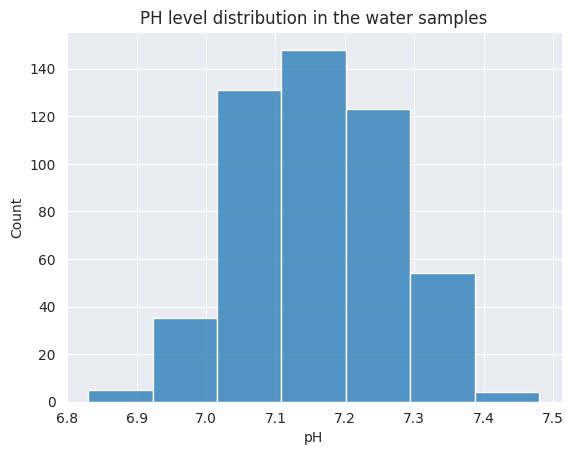

In [33]:
sns.set_style("darkgrid")
sns.histplot(data=df,x="pH",binwidth=0.1)
plt.title("PH level distribution in the water samples")
plt.show()

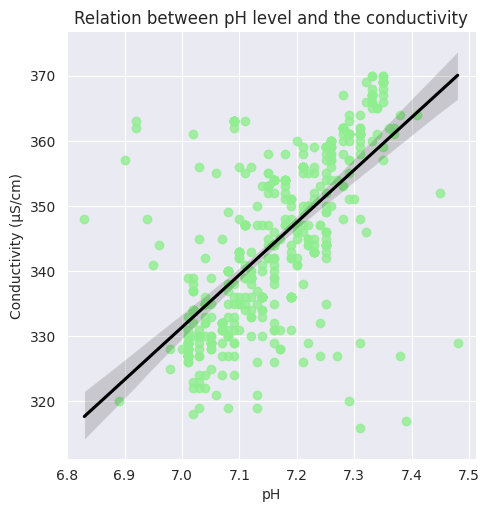

In [34]:
sns.lmplot(data=df,x="pH",y="Conductivity (µS/cm)",scatter_kws={'color':'lightgreen'},line_kws={'color':'black'})
plt.title("Relation between pH level and the conductivity")
plt.show()

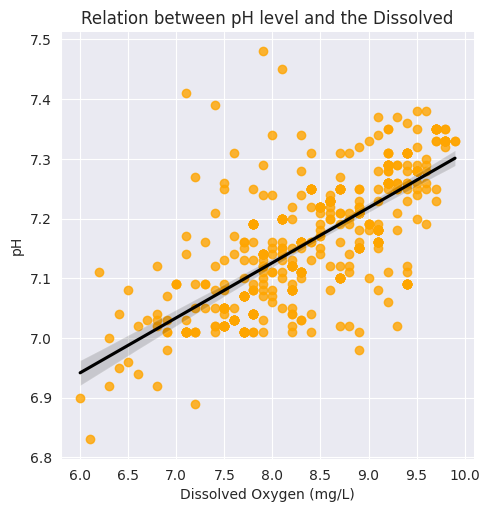

In [35]:
sns.lmplot(data=df,x="Dissolved Oxygen (mg/L)",y="pH",scatter_kws={'color':'orange'},line_kws={'color':'black'})
plt.title("Relation between pH level and the Dissolved")
plt.show()

# Clean Data

Basic Visualization

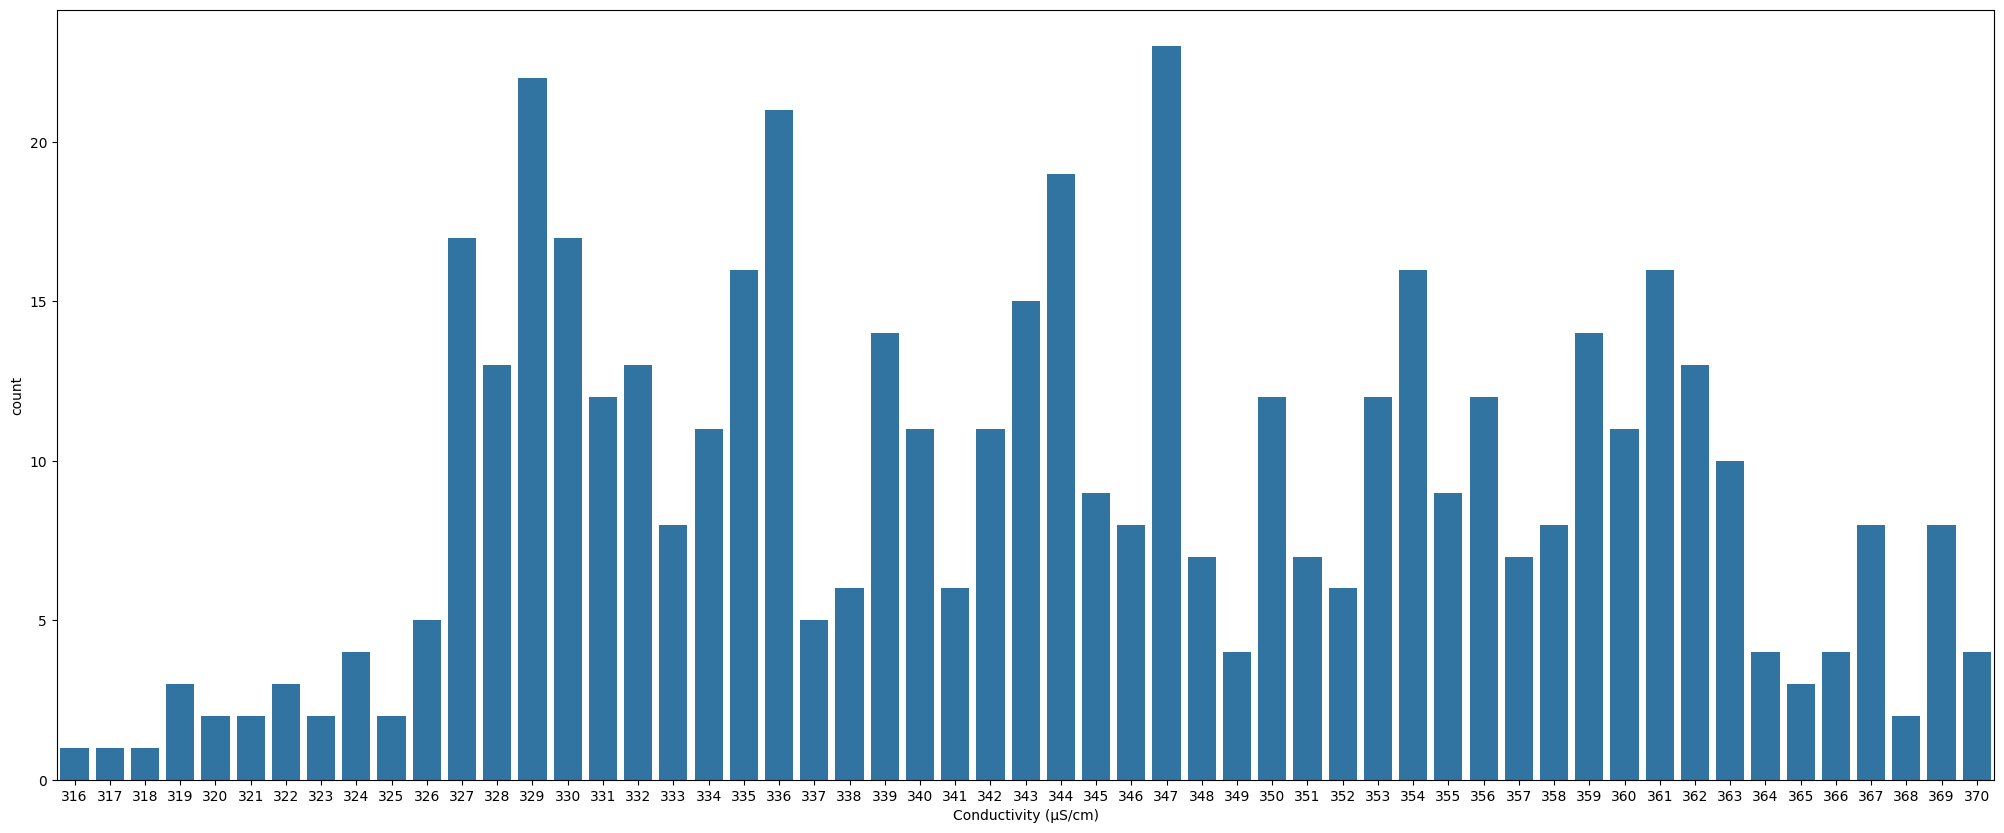

In [30]:
df = df.drop(columns=["Sample ID"])
plt.subplots(figsize=(25,10))
sns.countplot(data=df, x="Conductivity (µS/cm)")
plt.show()

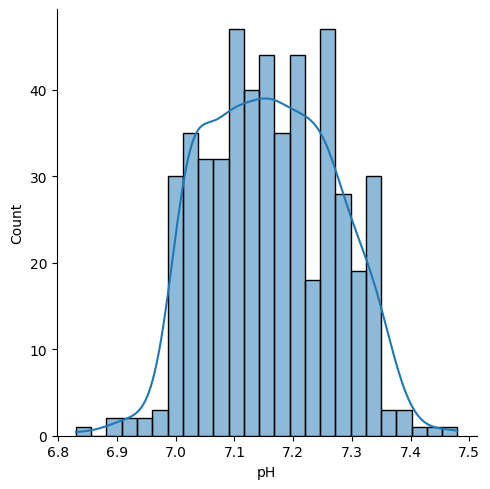

In [11]:
sns.displot(data=df, x="pH", kde=True, bins=25)
plt.show()

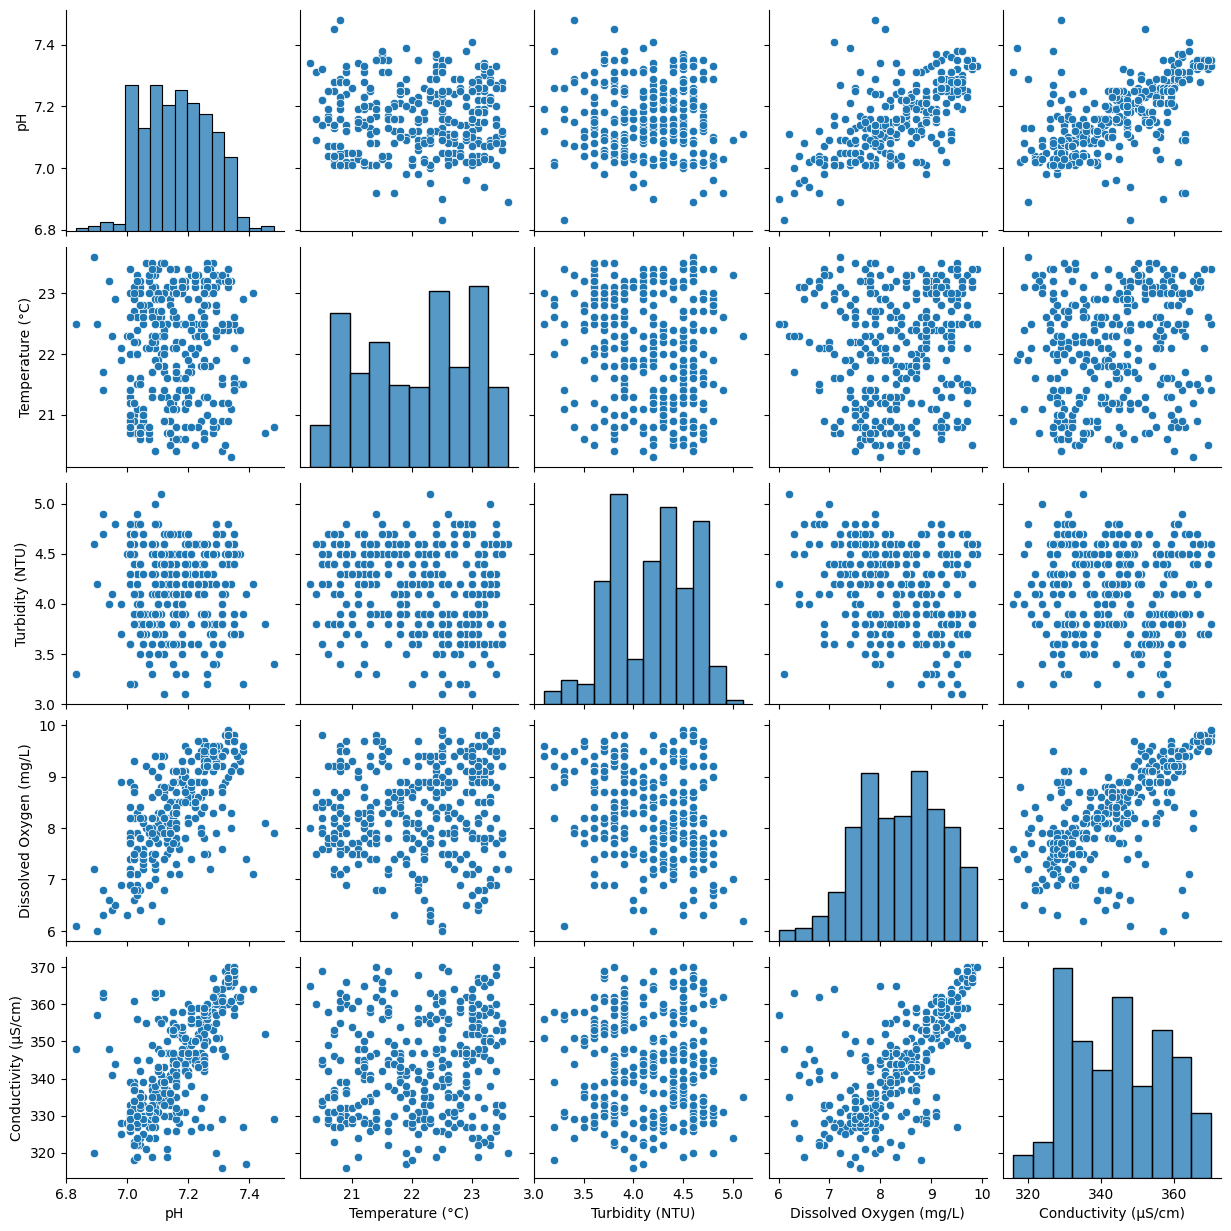

In [12]:
sns.pairplot(df)
plt.show()

In [45]:
def checks_null_values(df):
    '''
    Takes df
    Checks nulls
    '''
    if df.isnull().sum().sum() > 0:
        mask_total = df.isnull().sum().sort_values(ascending=False)
        total = mask_total[mask_total > 0]

        mask_percent = df.isnull().mean().sort_values(ascending=False)
        percent = mask_percent[mask_percent > 0] * 100

        missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).sort_values(by=['Total'], ascending=False)

        return missing_data
    else:
        print('No NaN found.')

def _check_df(df):
    # Empty Dataframe check
    assert df.shape[0]>0 and df.shape[1]>0 , "DataFrame is Empty"
    # duplicate columns check
    assert len(df.columns.values)==len(set(df.columns.values)) , "DataFrame has duplicate columns"


def most_common_value(df):
    # for simple cases use df.mode().T
    _check_df(df)
    total_rows = df.shape[0]
    columns,modes,counts = list(),list(),list()
    for column in df.columns:
        count = df[column].value_counts().max()
        mode = df[column].value_counts().index[0]
        columns.append(column)
        modes.append(mode)
        counts.append(count)
    description = pd.DataFrame(index=columns,data={"Most Frequent Value":modes,"Most Frequent Value Count":counts})
    description["Most Frequent Value %"] = 100 * description["Most Frequent Value Count"]/total_rows
    description.index.names = ["Column"]
    return description

def histogram_plot(df, numerical_columns):
    '''
    Takes df, numerical columns as list
    Returns a group of histagrams
    '''
    f = pd.melt(df, value_vars=numerical_columns)
    g = sns.FacetGrid(f, col='variable',  col_wrap=4, sharex=False, sharey=False)
    g = g.map(sns.distplot, 'value')
    return g


def heatmap_plot(df, dependent_variable):
    '''
    Takes df, a dependant variable as str
    Returns a heatmap of all independent variables' correlations with dependent variable
    '''
    plt.figure(figsize=(8, 10))
    g = sns.heatmap(df.corr()[[dependent_variable]].sort_values(by=dependent_variable),
                    annot=True,
                    cmap='coolwarm',
                    vmin=-1,
                    vmax=1)
    return g

def corr_list(df):

      return  (df.corr()
          .unstack()
          .sort_values(kind="quicksort",ascending=False)
          .drop_duplicates().iloc[1:]); df_out


def box_plot(df, col_name, title=None, xlabel=None):
    """
    Draw's a single horizontal boxplot
    Parameters
    ----------
    df : Pandas Data Frame
    col_name : column name in data frame
    title : Plot title
    xlabel : X-axis label
    ylabel : Y-axis label
    """
    fig = plt.figure(figsize=(10, 6))  # define plot area
    ax = fig.add_subplot(111)  # add single subplot
    sns.boxplot(df[col_name], ax=ax)  # Use seaborn plot
    if not title:
        title = 'Boxplot of {}'.format(col_name)
    ax.set_title(title)  # Give the plot a main title
    if not xlabel:
        xlabel = col_name
    ax.set_xlabel(xlabel)  # Set text for the x axis


def bar_plot(df, col_name, title=None, xlabel=None, ylabel='Count'):
    """
    Draw's a single bar plot
    Parameters
    ----------
    df : Pandas Data Frame
    col_name : column name in data frame
    title : Plot title
    xlabel : X-axis label
    ylabel : Y-axis label
    """
    fig = plt.figure(figsize=(10, 6))  # define plot area
    ax = fig.add_subplot(111)  # add single subplot
    ax = df[col_name].value_counts().plot.bar(
        color='steelblue')  # Use pandas bar plot
    if not title:
        title = 'Barplot of {}'.format(col_name)
    ax.set_title(title)  # Give the plot a main title
    if not xlabel:
        xlabel = f'No. of {col_name}'
    ax.set_xlabel(xlabel)  # Set text for the x axis
    ax.set_ylabel(ylabel)  # Set text for the y axis
# Check for null values inside the DF
checks_null_values(df)

No NaN found.


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packa

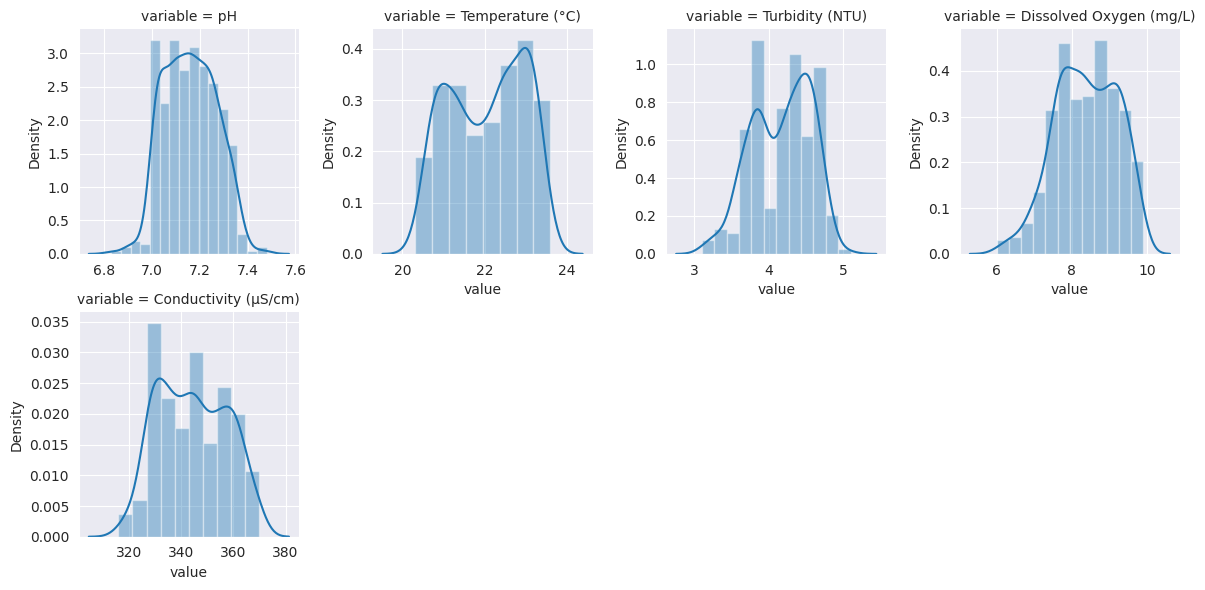

In [46]:
histogram_plot(df, ['pH', 'Temperature (°C)', 'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)', 'Conductivity (µS/cm)'])

# Cheking the values of sensors


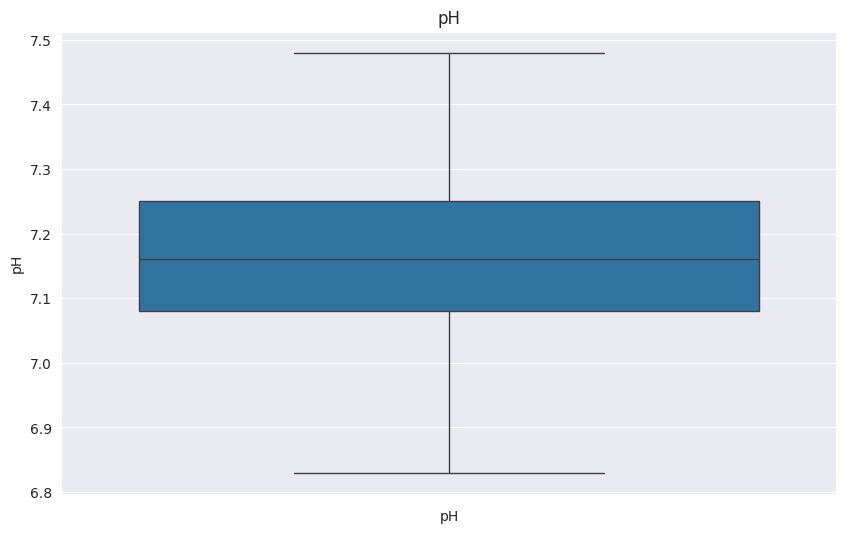

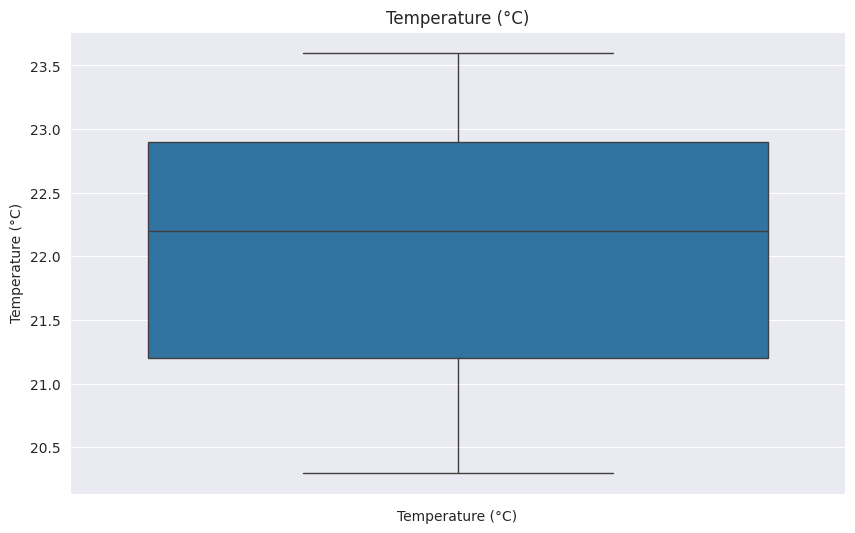

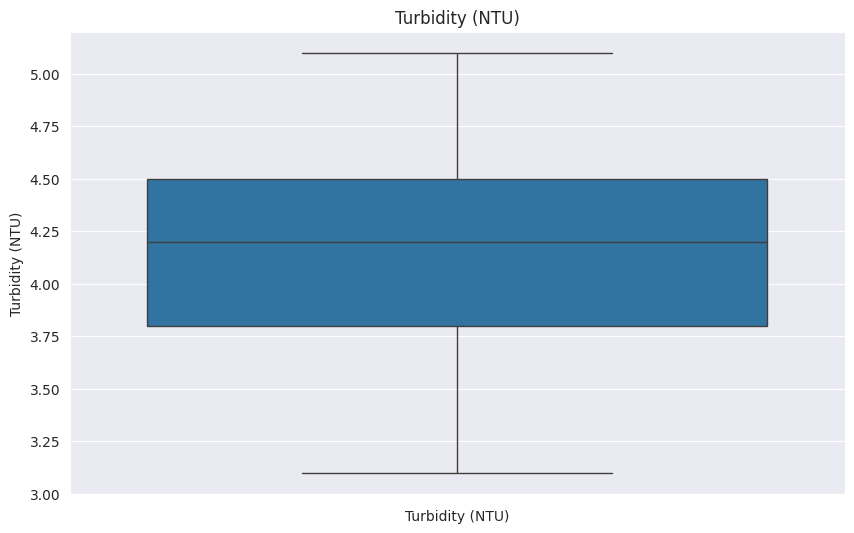

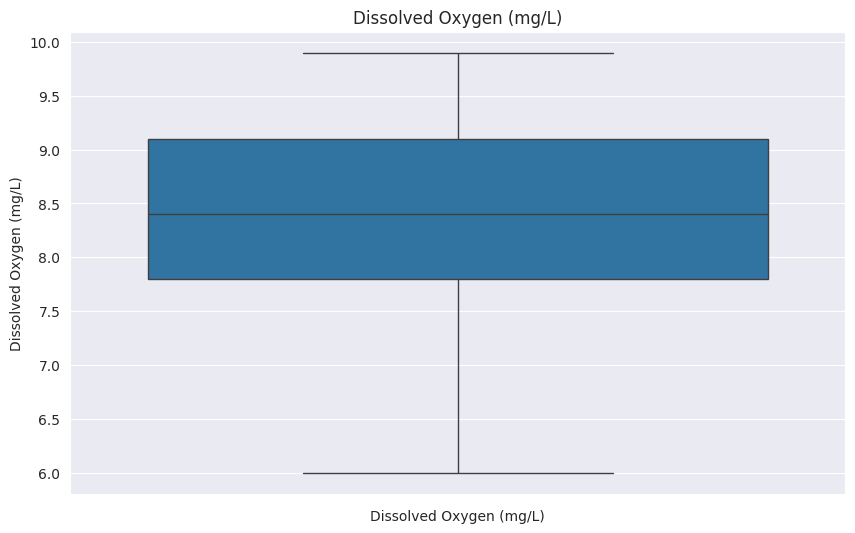

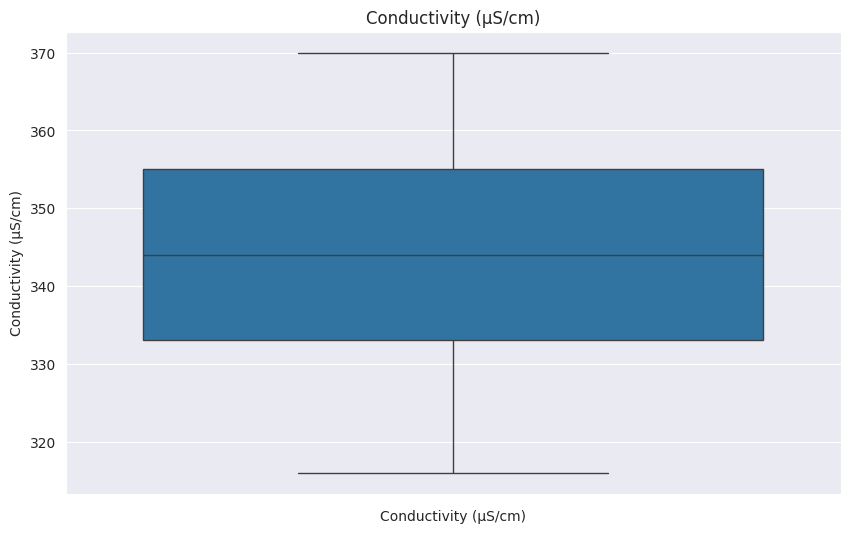

In [48]:
for column in df.columns:
    box_plot(df, column, title=column)

# Find Correlations and R squared values

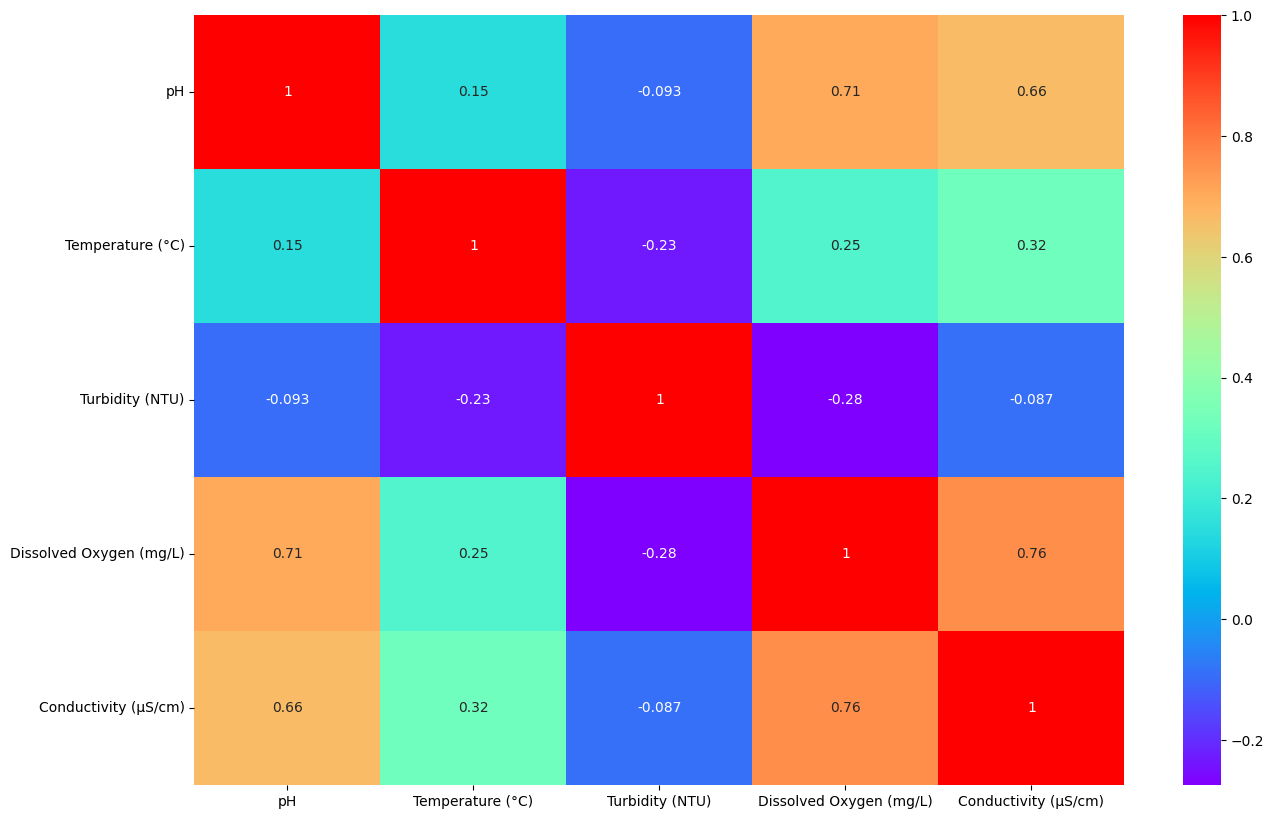

In [13]:
plt.subplots(figsize=(15,10))
sns.heatmap(df.corr(), cmap="rainbow", annot=True)
plt.show()

In [14]:
corr_L = []
for column in df.drop(["pH"], axis=1).columns:
    corr_L.append(df[column].corr(df["pH"]))
max_corr_index = np.argmax(corr_L)
print(corr_L)
max_corr = df.drop(["pH"], axis=1).columns[max_corr_index]
max_corr

[0.15237424726324764, -0.09285963571524329, 0.7052479638352956, 0.6642316007626193]


'Dissolved Oxygen (mg/L)'

In [15]:
np.max(corr_L)

0.7052479638352956

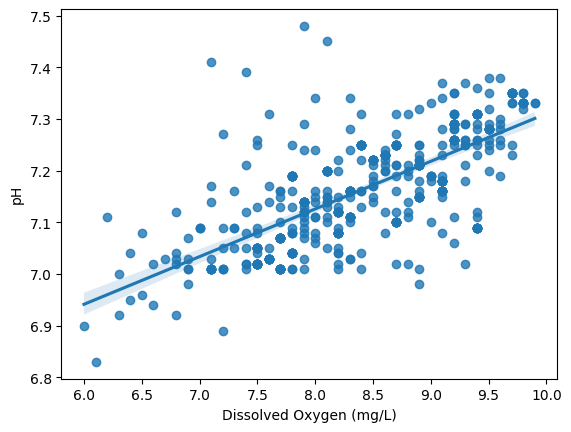

In [16]:
sns.regplot(data=df, y="pH", x="Dissolved Oxygen (mg/L)")
plt.show()

In [17]:
x = df["pH"]
y = df["Dissolved Oxygen (mg/L)"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x,y)

In [18]:
r_value

0.7052479638352955

In [19]:
p_value

2.0593784987364177e-76

In [20]:
r_squared = r_value**2
r_squared

0.4973746904938303

In [21]:
col = []
data = []
for column in df.drop(["pH"], axis=1).columns:
    y = df[column]
    x = df["pH"]
    col.append(column)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    data.append([slope, intercept, r_value, p_value, std_err])

df_r = pd.DataFrame(data, columns=["Slope", "Intercept", "R-Value", "P-Value", "Std Err"], index=col)

In [22]:
df_r["R2-Value"] = df_r["R-Value"]**2
df_r

,Slope,Intercept,R-Value,P-Value,Std Err,R2-Value
Temperature (°C),1.279755,12.889899,0.152374,6.293335e-04,0.371963,0.023218
Turbidity (NTU),-0.343260,6.627532,-0.092860,3.792224e-02,0.164930,0.008623
Dissolved Oxygen (mg/L),5.393753,-30.243219,0.705248,2.059378e-76,0.242972,0.497375
Conductivity (µS/cm),80.541720,-232.408534,0.664232,6.249383e-65,4.061753,0.441204


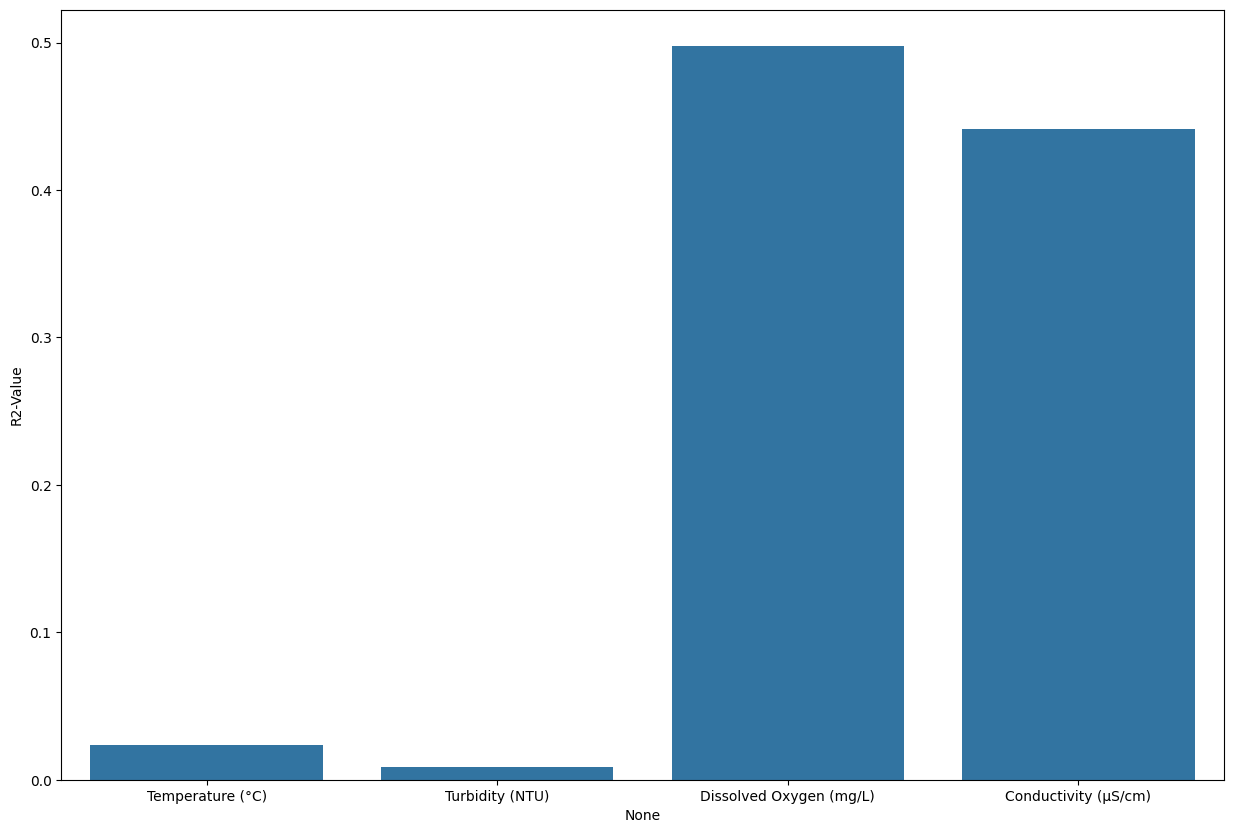

In [23]:
plt.subplots(figsize=(15,10))
sns.barplot(data=df_r, x=df_r.index, y="R2-Value")
plt.show()

# Using the Kmeans Model to classify the water sample into 3 **category**

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df)

StandardScaler(copy=True,with_mean=True,with_std=True)

sampled_scaler = scaler.transform(df)

In [39]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3,random_state=2023)

cluster = model.fit_predict(sampled_scaler)

level = pd.Series(cluster)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


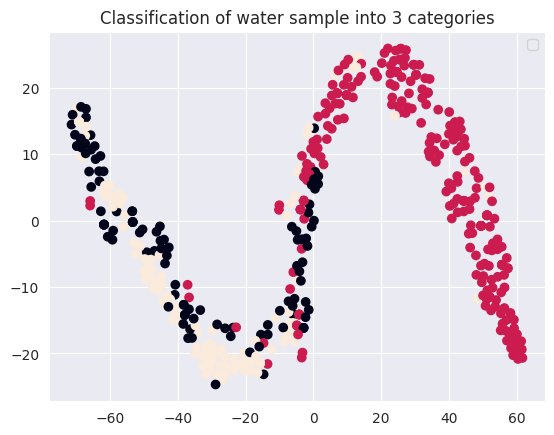

In [40]:
from sklearn.manifold import TSNE

model = TSNE()

transformed_model = model.fit_transform(df)

xs = transformed_model[:,0]
ys =transformed_model[:,1]

plt.scatter(xs,ys,c=level)
plt.title("Classification of water sample into 3 categories")
plt.legend()
plt.show()

Start of ML part

In [24]:
y = df["Dissolved Oxygen (mg/L)"]
features = ["pH", "Temperature (°C)", "Turbidity (NTU)", "Conductivity (µS/cm)"]
X = df[features]
X.head(3)

,pH,Temperature (°C),Turbidity (NTU),Conductivity (µS/cm)
0,7.25,23.1,4.5,342
1,7.11,22.3,5.1,335
2,7.03,21.5,3.9,356


In [25]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=42)
rf_model = RandomForestRegressor(random_state=1)
rf_model.fit(X, y)
rf_val_predictions = rf_model.predict(val_X)
mae = mean_absolute_error(rf_val_predictions, val_y)
mse = mean_squared_error(rf_val_predictions, val_y)
r2 = r2_score(rf_val_predictions, val_y)

In [26]:
print("Validation MAE for Random Forest Model: {:,f}".format(mae))
print("Validation MSE for Random Forest Model: {:,f}".format(mse))
print("Validation R2 for Random Forest Model: {:,f}".format(r2))

Validation MAE for Random Forest Model: 0.083464
Validation MSE for Random Forest Model: 0.024441
Validation R2 for Random Forest Model: 0.958370


Decision Tree

Based on CSV file


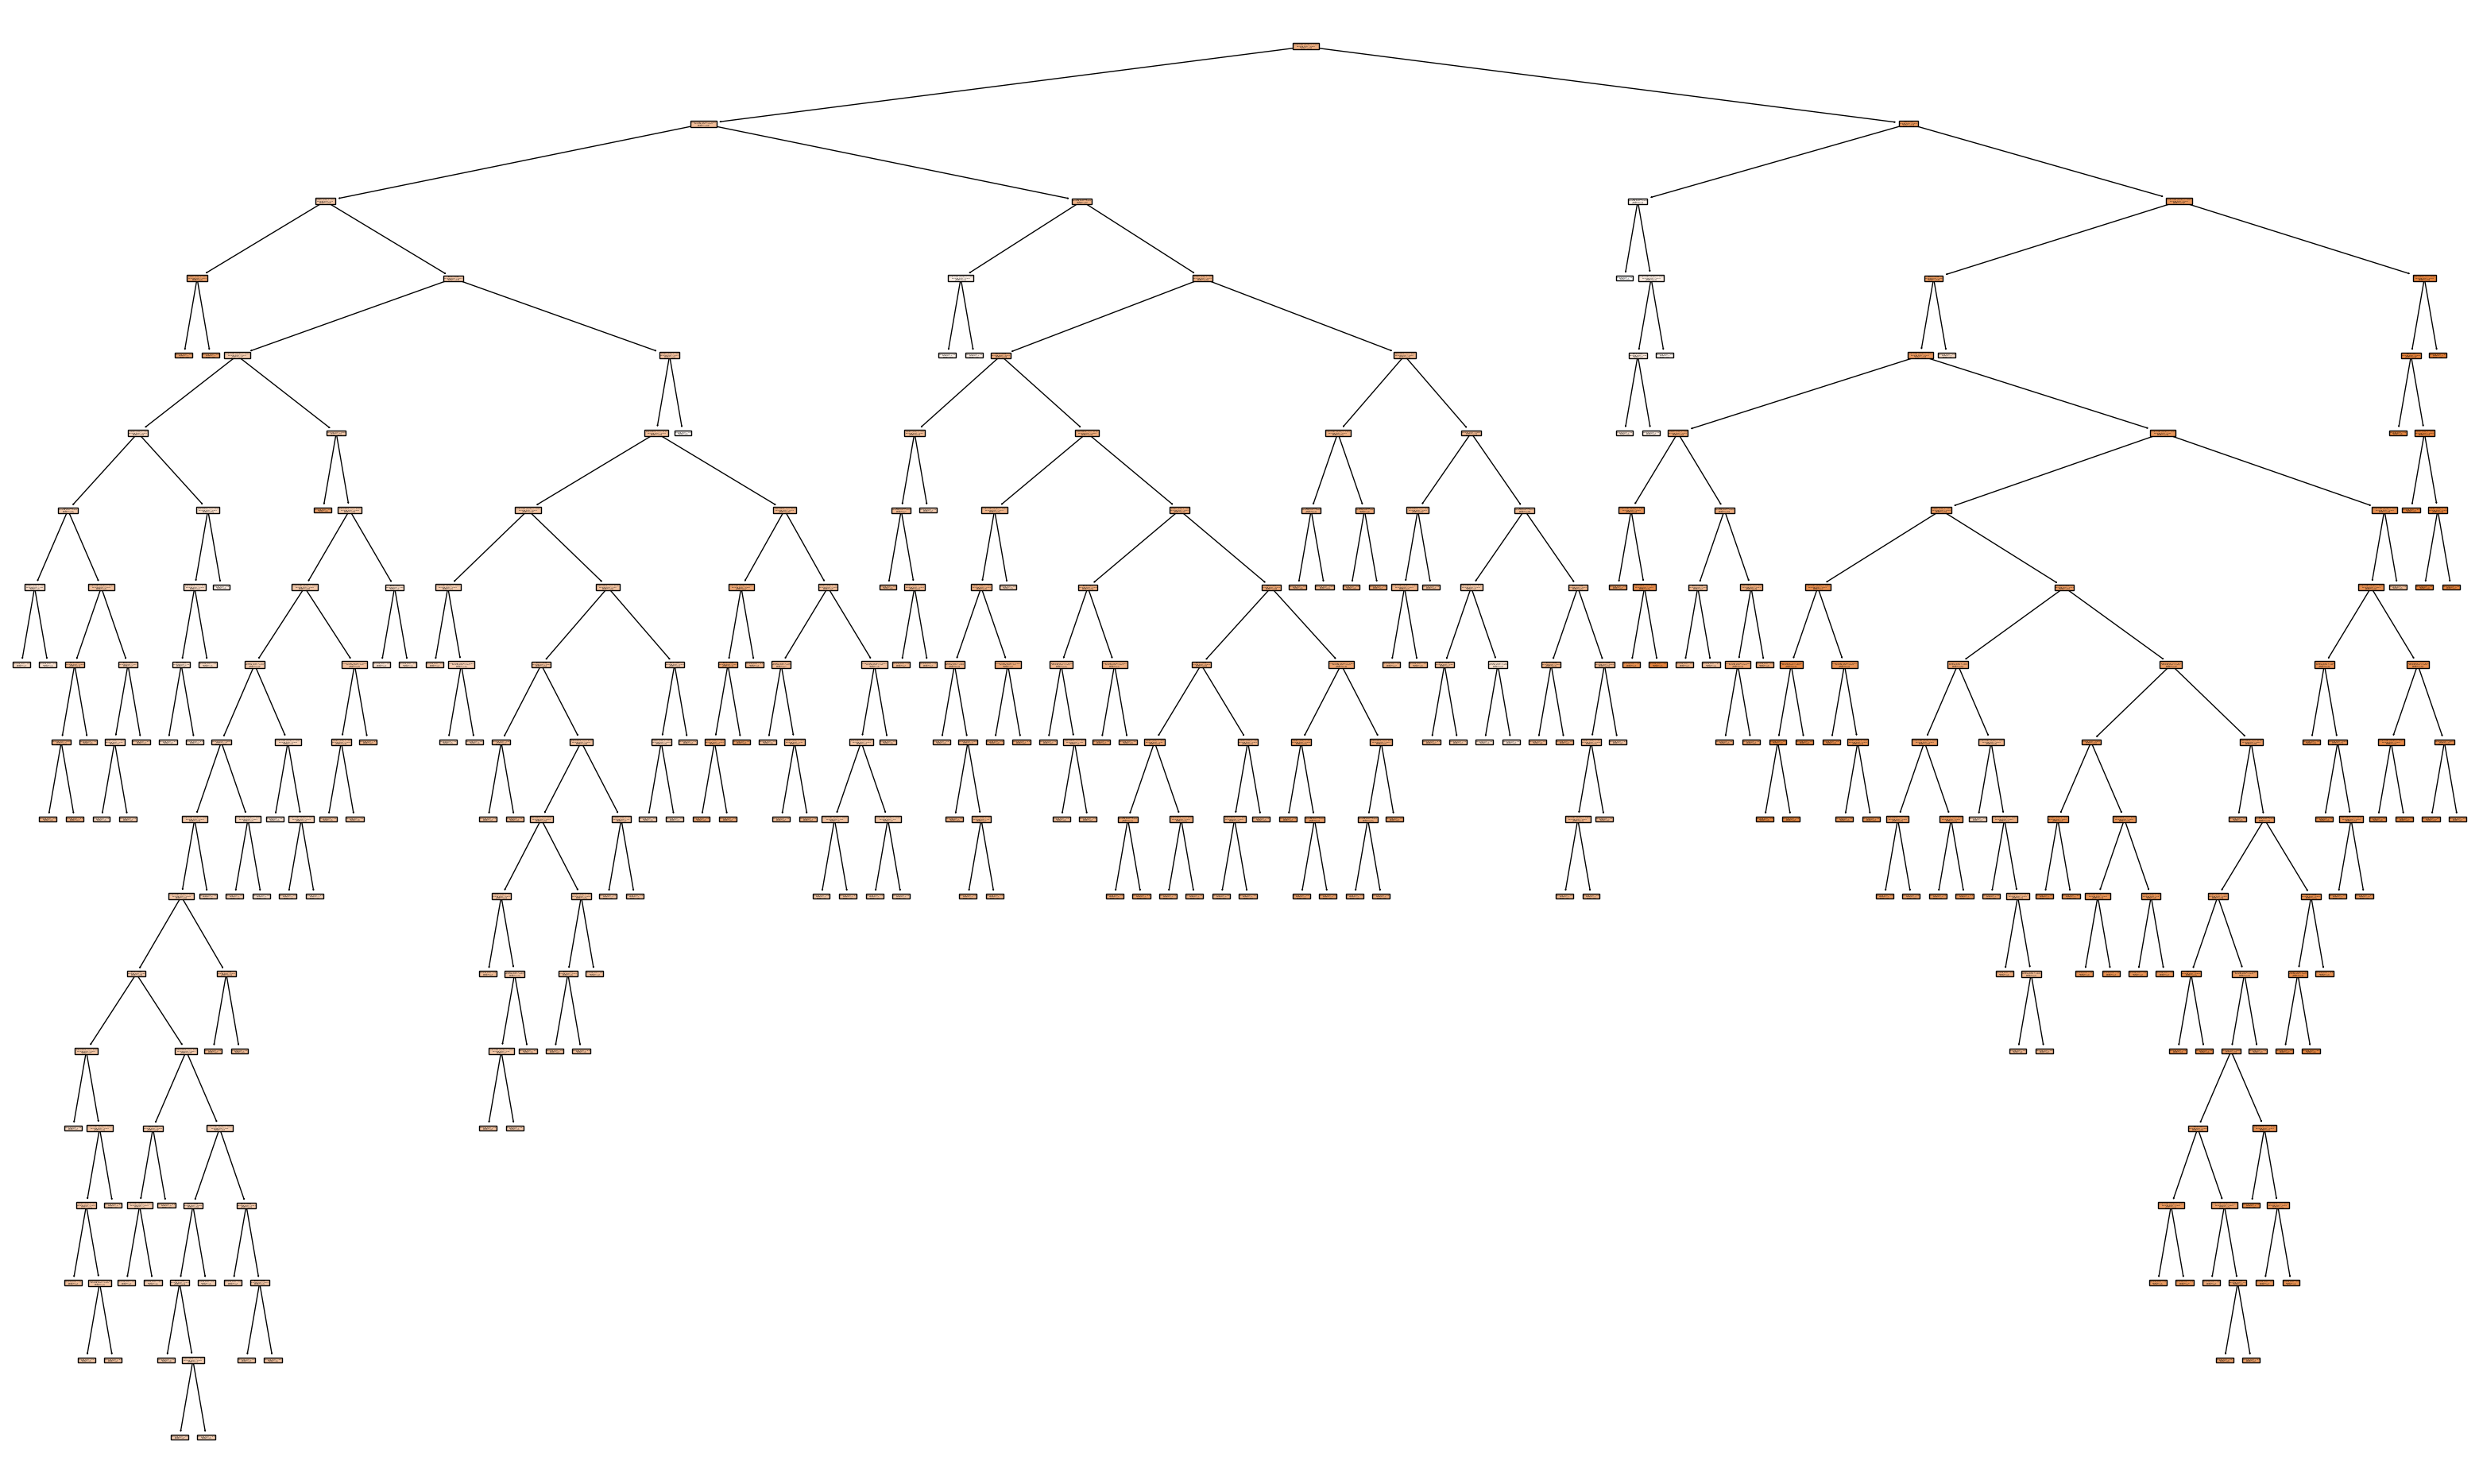

In [31]:
plt.figure(figsize=(40, 24))
plot_tree(rf_model.estimators_[0], feature_names=features, filled=True)
plt.savefig("decision_tree.png", format="png")
plt.show()